In [2]:
# Imports
from IPython.display import HTML
import numpy as np
import glob
import winnie
from winnie.plot import animate_quick_implot, quick_implot, mpl, plt
from spaceKLIP import database
import astropy.units as u
import stpsf
from winnie.modeling import (grater_2hg_disk_model, grater_nring_2hg_disk_model, obj_fn, lmfit_nrings_nptsrc_init, make_region_of_interest_mask)
from winnie.utils import (dist_to_pt, ang_size_to_px_size, ang_size_to_proj_sep, px_size_to_ang_size)
import lmfit

plt.style.use('winnie.winnie_mplstyle') # Comment this out or replace it if you prefer a different plot style

winnie.utils.setup_jupyter_display()

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


### In this tutorial, we'll explore some options for using / fitting a multi-component model with Winnie. 

For ease, we're going to use the same example AU Mic dataset. Instead of masking the marginally resolved background galaxy near the disk, we'll fit it as a point-like source alongside the disk. 

Additionally, we'll add an arbitrary background offset to the data to show how such a nuisance component can be included in our composite model. In this case, the added background component is uniform — so more like an artificially induced background offset than a residual astrophysical background. 

In [3]:
# Prep the SpaceRDI object:
distance = 9.714 # Distance to your target in parsecs

base_dir = './aumic_rdi_example/'
input_dir = f'{base_dir}coadded/'
data_ext = 'calints'
fitsfiles = np.sort(glob.glob(f'{input_dir}*{data_ext}.fits')) # Populate a file list

# Initialize the spaceKLIP database
Database = database.Database(base_dir)
Database.verbose = False
Database.read_jwst_s012_data(datapaths=fitsfiles)

# Create the SpaceRDI object we'll use to carry out RDI
wdb = winnie.SpaceRDI(Database, output_subdir='WinnieRDI_tutorial6', overwrite=True, verbose=False, pad_data='auto')

# Spectrum to assume for the convolution PSFs; ck04 doesn't have an M1, so we're just using an M0V instead.
spec_synphot = stpsf.specFromSpectralType('M0V', catalog='ck04')

wdb.prepare_convolution(spec_synphot, fov_pixels=151, osamp=2, grid_kwargs=dict(nr=10, ntheta=4), convolver_basedir=base_dir+'WinnieRDI/')

wdb.load_concat(1)

# This is our fake background offset so we have something to fit
wdb._imcube_sci += -0.5

Setting up sim to match ./aumic_rdi_example/coadded/jw01184001001_03106_00001_nrcalong_calints.fits

MAST OPD query around UTC: 2022-10-03T05:53:34.311
                        MJD: 59855.24553600694

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/O2022100201-NRCA3_FP1-1.fits
	Date (MJD):	 59854.1754
	Delta time:	 -1.0701 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2022100401-NRCA3_FP1-1.fits
	Date (MJD):	 59856.3241
	Delta time:	 1.0786 days
User requested choosing OPD time closest in time to 2022-10-03T05:53:34.311, which is O2022100201-NRCA3_FP1-1.fits, delta time -1.070 days
Importing and format-converting OPD from /Users/klawson/jwst/data/stpsf-data/MAST_JWST_WSS_OPDs/O2022100201-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)
Sensing inst model using apername NRCA3_FP1
Using sensing field point SI WFE model from file wss_target_phase_fp1.fits

Configured simulation inst

Since our 'point-like' source here is a slightly resolved background galaxy, we use `ptsrc_sky_blur='gaussian2d'` in our param initialization arguments to include a sky-frame blurring of the point source with a 2D gaussian kernel to improve the fit.

Something like a Sersic profile would likely work better, but is unnecessarily complex for such a marginally resolved source.

If you want to crudely approximate a detector effect like BFE with a gaussian kernel, you could use `ptsrc_det_blur='gaussian1d'` instead.

In [4]:
# use some params from our prior disk fit to keep the fitting process short for tutorial purposes
h_diskfit = winnie.SpaceReduction(f'{wdb.convolver.output_basedir}{wdb.concat}_cssmodel_i2d.fits').primary_header

ring_params=[dict(r0=32.04, # set initial value and use default ranges for min/max
                  pa=[130., 126., 134.],
                  incl=[89., 88., 89.75],
                  ain=[3.,1.,10.], # or set initial, min, and max value
                  aout=[-3.,-10.,-1.],
                  h0=0.038,
                  gamma=1.5)]

ptsrc_params = [dict(dx=-1.06, 
                     dy=-3.22)]

p = lmfit_nrings_nptsrc_init(ptsrc_params=ptsrc_params, 
                             ring_params=ring_params, 
                             ptsrc_dxy_range=0.2, 
                             ptsrc_sky_blur='gaussian2d')

p['r0_1'].vary = False
p['h0_1'].vary = False

p['ptsrc_skyxsig_1'].value = 3.0
p['ptsrc_skyysig_1'].value = 0.5
p['ptsrc_skytheta_1'].value = 30.

for key in ['incl_1', 'g1_1', 'g2_1', 'wg1_1']:
    p[key].value = h_diskfit[key]
    p[key].vary = False

p

name,value,initial value,min,max,vary
r0_1,32.0400000,32.04,1.00000000,1000.00000,False
pa_1,130.000000,130.0,126.000000,134.000000,True
incl_1,89.1000000,89.0,88.0000000,89.7500000,False
ain_1,3.00000000,3.0,1.00000000,10.0000000,True
aout_1,-3.00000000,-3.0,-10.0000000,-1.00000000,True
h0_1,0.03800000,0.038,1.0000e-03,0.10000000,False
beta_1,1.00000000,1.0,0.00000000,2.00000000,False
gamma_1,1.50000000,1.5,0.10000000,6.00000000,False
e_1,0.00000000,0.0,0.00000000,0.90000000,False
omega_1,0.00000000,0.0,-90.0000000,90.0000000,False


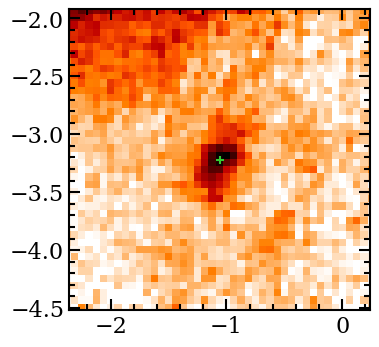

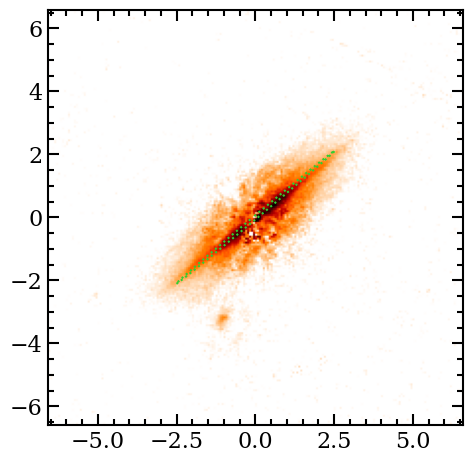

In [5]:
# Before proceeding, you can optionally inspect your indicated model components are correct.
# For point sources near the IWA, I'd suggest making sure that the positions are as close as
# possible by-eye so we can avoid generating a PSF model for every trial.

wdb.set_crop()
wdb.hpfrdi_presets()
plot_reduc = wdb.run_rdi() # Reduc to use for plotting

Nptsrc = (0 if ptsrc_params is None else len(ptsrc_params))
Nring = (0 if ring_params is None else len(ring_params))

if Nptsrc != 0:
    winsz_nfwhm = 15 # FOV size for the subplots; 15 lambda/D in this case

    winsz = winnie.utils.px_size_to_ang_size(winsz_nfwhm*wdb._fwhm, wdb.pxscale).value 

    fig,axes = plt.subplots(1, Nptsrc, figsize=(4*Nptsrc, 4))

    if Nptsrc == 1:
        axes = [axes]

    for i,entry in enumerate(ptsrc_params):
        ax = axes[i]
        dx, dy = entry['dx'], entry['dy']
        cmask = winnie.utils.dist_to_pt(winnie.utils.ang_size_to_px_size(np.array([dx, dy]), plot_reduc.pxscale).value+plot_reduc.c_star, plot_reduc.nx, plot_reduc.ny) < 5*wdb._fwhm
        clim = winnie.plot.percentile_clim(np.where(cmask, plot_reduc.im, np.nan), [1, 99.99])

        fig,ax = quick_implot(plot_reduc.im, cmap='gist_heat_r', clim=clim, show=False, show_ticks=True, extent=plot_reduc.extent, fig_and_ax=(fig,ax), sharex=False, sharey=False)
        ax.scatter(dx, dy, marker='+', c='limegreen')
        ax.set(xlim=dx+np.array([-winsz/2, winsz/2]), 
               ylim=dy+np.array([-winsz/2, winsz/2]))

    plt.show()
    
if Nring != 0:
    max_r0 = np.max([entry['r0'] for entry in ring_params])
    plot_reduc.generate_rmaps()
    
    lims = np.array([-2, 2])*winnie.utils.proj_sep_to_ang_size(max_r0, distance).value
    cmask = plot_reduc.rmap_arcsec <= lims[1]
    clim = np.array([0, 1])*np.nanpercentile(np.where(cmask, plot_reduc.im, np.nan), 99.99)
    fig,ax = quick_implot(plot_reduc.im, cmap='gist_heat_r', clim=clim,
                          norm=mpl.colors.Normalize, norm_kwargs=dict(clip=True), lims=lims,
                          show=False, show_ticks=True, extent=plot_reduc.extent)

    for i,entry in enumerate(ring_params):
        dx, dy = winnie.utils.disk_profile_xy(winnie.utils.proj_sep_to_ang_size(p[f'r0_{i+1}'].value, distance).value,
                                              p[f'incl_{i+1}'].value, 
                                              p[f'pa_{i+1}'].value)
        
        ax.plot(dx, dy, c='limegreen', ls='dotted')

    plt.show()
    
plot_reduc = None

In [6]:
# Generate STPSF hduls for the point-like sources (one per roll per source) if needed
if ptsrc_params is None or len(ptsrc_params) == 0:
    ptsrc_hduls = None
else:
    ptsrc_spectrum = stpsf.specFromSpectralType('M2V', catalog='ck04')
    wdb.convolver.calc_psf_shift(source_spectrum=ptsrc_spectrum)

    # If you're working with a bright source where you detect the PSF wings to large seps, 
    # nlambda_ptsrc needs to be larger than the default used here! 
    # nlambda ~ 50 should work across the FOV for wide filters
    # likewise, a larger fov_pixels will be needed
    nlambda_ptsrc = wdb.convolver._psfcube_off.shape[0]
    ptsrc_weights = winnie.convolution.source_spectrum_to_weights(ptsrc_spectrum, wdb.convolver.inst_webbpsfext.bandpass, nlambda=nlambda_ptsrc)
    ptsrc_hduls = winnie.modeling.generate_ptsrc_hduls(wdb, ptsrc_params, spectrum=ptsrc_weights, fov_pixels=75, osamp=2, nlambda=nlambda_ptsrc)

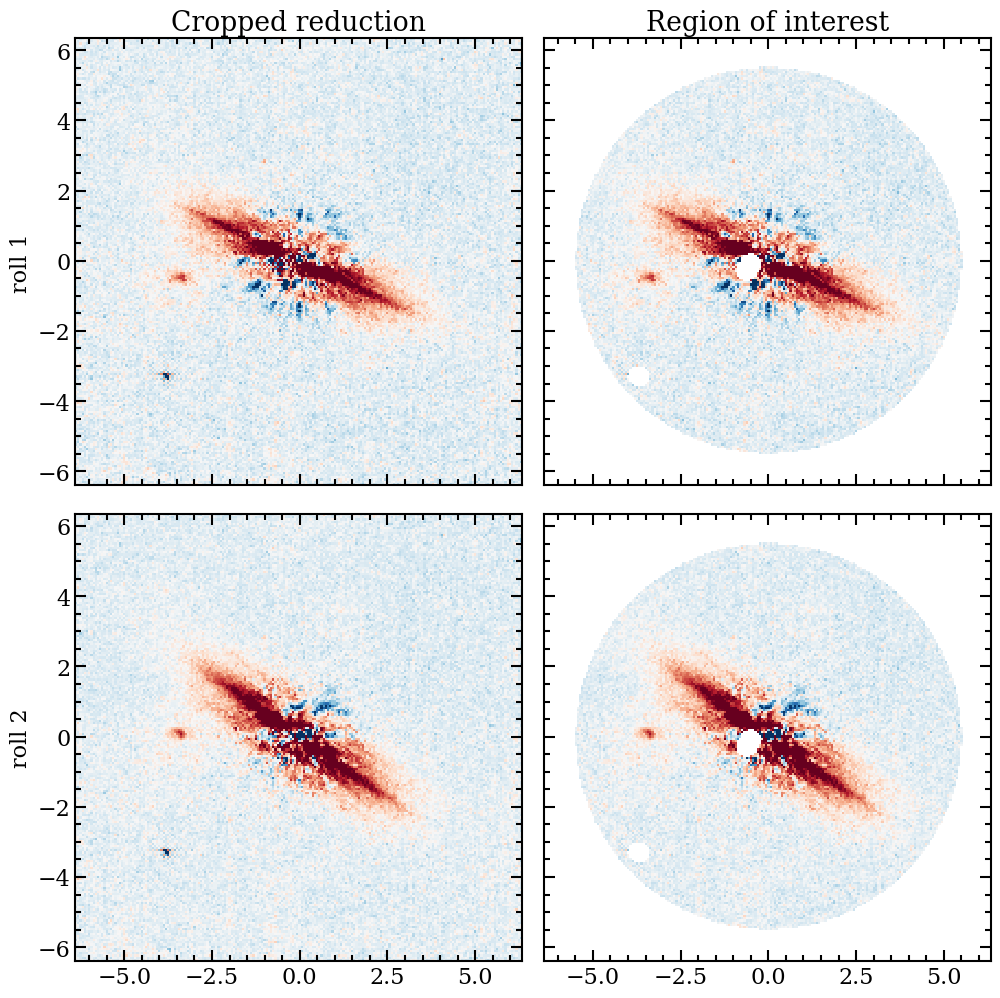

In [7]:
# Region of interest (ROI) settings:
roi_units = u.arcsec # Units for specifying the ROI; should work for u.pix or any angular units (u.arcsec, u.mas, u.deg, etc.)
roi_rmax = 5.5 # max radius (in units of roi_units) to include in the ROI
roi_rmin = 0.0 # min radius (in units of roi_units) to include in the ROI

# Detector positions (non-derotated) for any places to exclude from the ROI (for instrumental nuisance sources)
dxy_detector = np.array([[-0.62, -0.28], [-0.52, -0.1], [-3.70, -3.30]]) # in units indicated by roi_units
rexcl_detector = 0.3 # radius about each detector pos to exclude; either a single value or a list of values having the same length of dxy_detector

# North-up sky positions to exclude from the ROI (for astrophysical nuisance sources)
dxy_northup = None
rexcl_northup = None

q_clip = None # see obj_fn docstring
err_weighting = True # see obj_fn docstring

###################
wdb.rdi_presets() # Set back to presets for a standard RDI reduction

# Cropped size to use during optimization. Should be large enough to include the entire disk (or at least the part you're interested in) plus some padding for convolution
npx_crop = int(2*(np.ceil(ang_size_to_px_size(roi_rmax, wdb.pxscale).value + 5*wdb._fwhm)))
crop_size = [npx_crop, npx_crop] # Cropped shape

wdb.set_crop(crop_size)
y1,y2,x1,x2 = wdb._crop_indices

# Rerun RDI on the cropped data:
rdi_reduc = wdb.run_rdi(save_products=False, derotate=False, correct_distortion=False)

# Generate the boolean region of interest mask
roi = make_region_of_interest_mask(rdi_reduc, wdb, rmin=roi_rmin, rmax=roi_rmax, dxy_northup=dxy_northup, rexcl_northup=rexcl_northup, dxy_detector=dxy_detector, rexcl_detector=rexcl_detector, units=roi_units)

# The largest separation (in au) at which to calculate the disk model. Here, we truncate the calculation at ~ the edge of the cropped FOV
rmax_accuracy = ang_size_to_proj_sep(px_size_to_ang_size(npx_crop/2., wdb.pxscale), distance).value # Convert to au

fig,axes = quick_implot(np.array([rdi_reduc.rolls, np.where(roi, rdi_reduc.rolls, np.nan)]).transpose((1,0,2,3)), 
                             interpolation='None', cmap='RdBu_r', clim_perc=99, show=False,
                             show_ticks=True, extent=rdi_reduc.extent)

axes[0].set_title('Cropped reduction')
axes[1].set_title('Region of interest')
for i in range(len(rdi_reduc.rolls)):
    axes[::2][i].set_ylabel(f'roll {i+1}')
    
plt.show()

Here, we're modeling our astrophysical scene as the superposition of a point source, a ring-like disk, and a uniform background.

We could modify the `obj_fn` and add an additional parameter for background brightness. But since RDI is linear, 
we can forward model a normalized uniform 'model' image just once and then have `obj_fn` use matrix inversion to 
determine the optimal scaling factor for all three of our components at the same time. This scaling factor for the forward-modeled background component then corresponds to the optimal scaling factor for the input background model as well.

To do this, we just need to pass in the lists we prepare in the cell below.

In [8]:
wdb.set_circumstellar_model(model_cube=np.ones_like(wdb.imcube_sci)) # Set the uniform "background model"

modelcubes_in = [wdb.imcube_css.copy()] # Store the input cube in modelcubes_in
modellabels_in = ['bg'] # Add a label for this model component
fmreducs_in = [wdb.run_rdi(forward_model=True, derotate=rdi_reduc.derotated, correct_distortion=rdi_reduc.distortion_corrected)] # Forward model the component to match our data
autoscale_in = [True] # Indicate to obj_fn that we want this component's brightness to be scaled rather than fixed

kws = dict(err_weighting=err_weighting, q_clip=q_clip, rmax_accuracy=rmax_accuracy, ptsrc_hduls=ptsrc_hduls, distorted_coords=True,
           modelcubes_in=modelcubes_in, modellabels_in=modellabels_in, fmreducs_in=fmreducs_in, autoscale_in=autoscale_in)

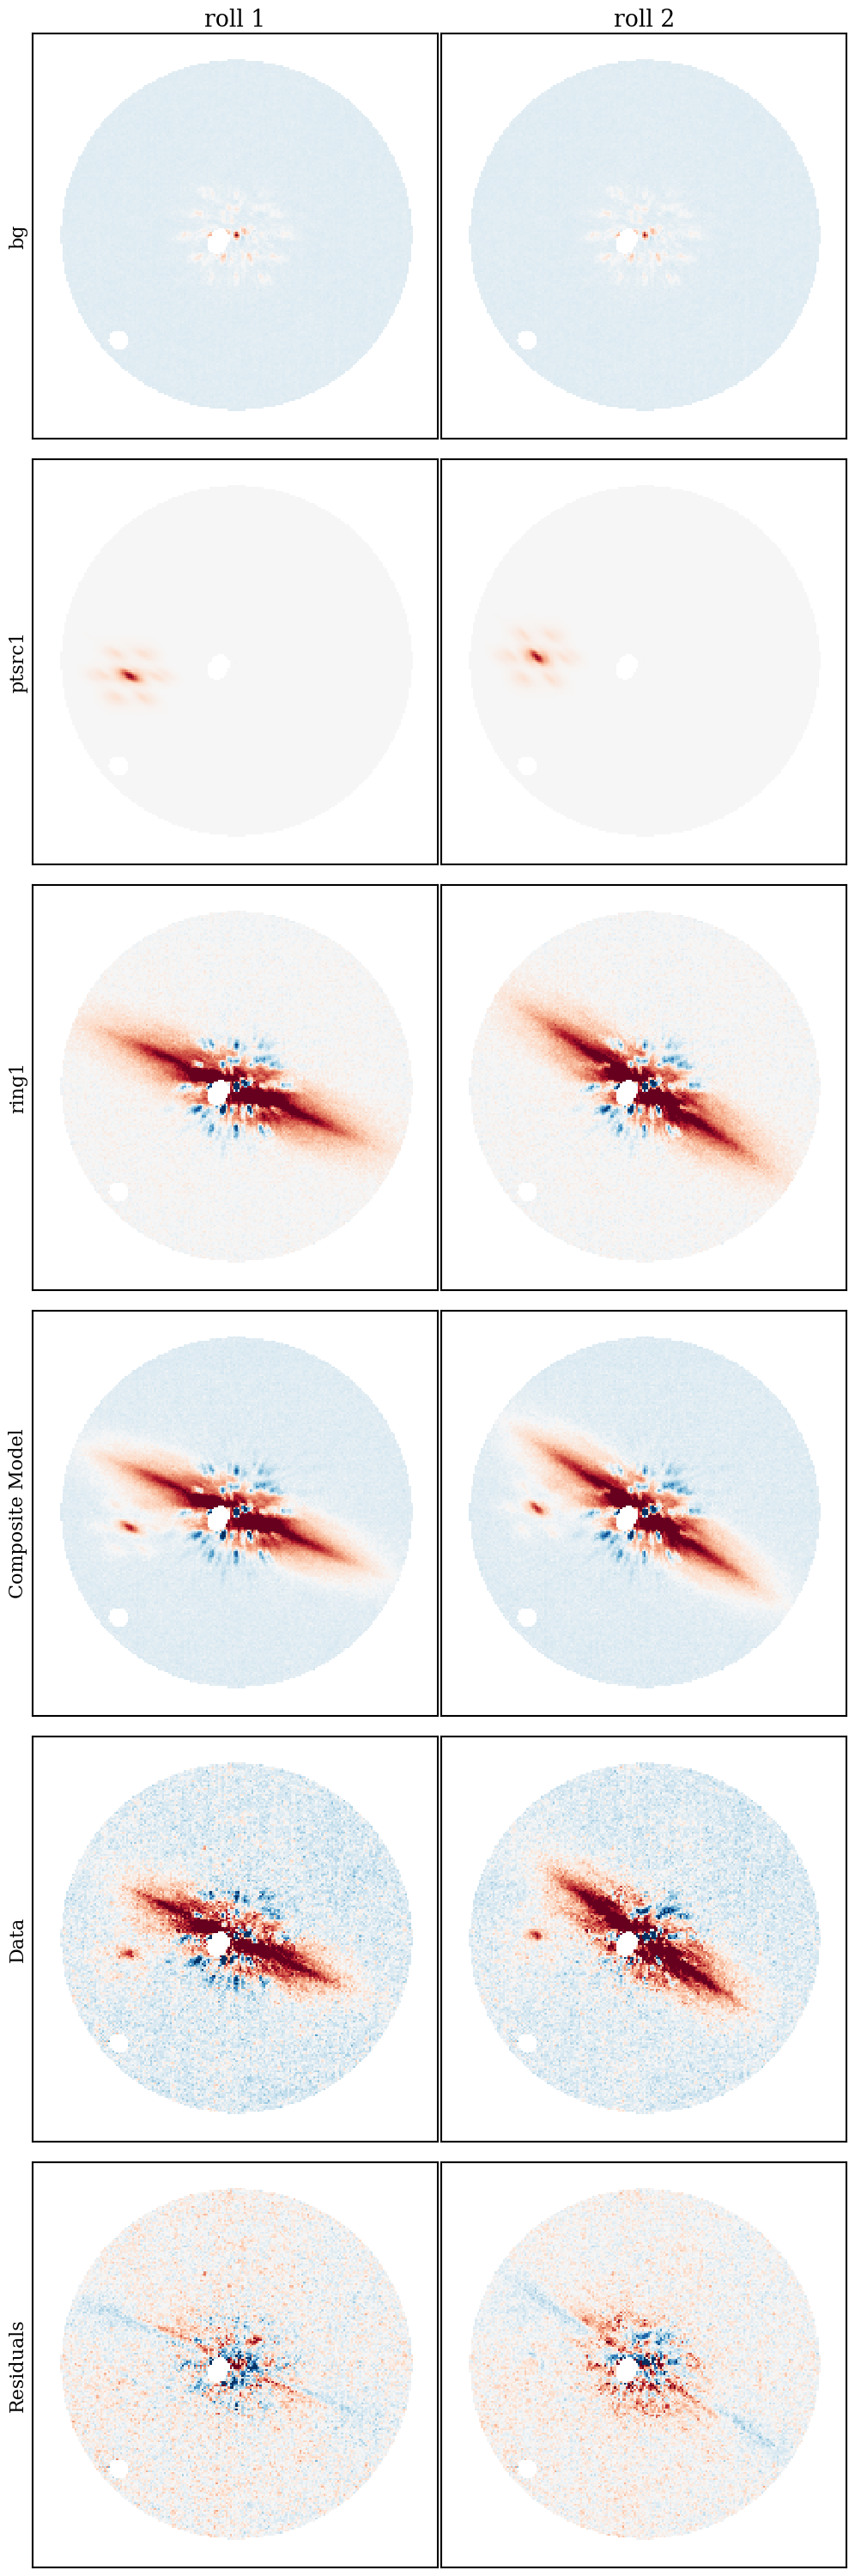

In [9]:
# Run a test model using the initialization and plot the result
out = obj_fn(p, rdi_reduc, wdb, roi, distance, count=False, halfNbSlices=25, return_soln=True, **kws)

modelcoeffs, modellabels, modelcubes, fmreducs, fmrdi_reduc, modelcube_composite, raw_disk_components, autoscale = out

pim = np.array([*[fmreduc.rolls for fmreduc in fmreducs], fmrdi_reduc.rolls, rdi_reduc.rolls, rdi_reduc.rolls-fmrdi_reduc.rolls])
labels = [*modellabels, 'Composite Model', 'Data', 'Residuals']
fig,axes = quick_implot(np.where(roi, pim, np.nan), clim_perc=99., cmap='RdBu_r', show=False, interpolation='None')

for i,label in enumerate(labels):
    axes[::len(rdi_reduc.rolls)][i].set_ylabel(label)
    
for i in range(len(rdi_reduc.rolls)):
    axes[i].set_title(f'roll {i+1}')
    
plt.show()

In [10]:
# Carry out the optimization procedure (should take ~300 iterations)
winnie.modeling.counter = 0

res = lmfit.minimize(obj_fn, p, method='powell',
                     args=[rdi_reduc, wdb, roi, distance], nan_policy='omit',
                     kws=dict(count=True, halfNbSlices=25, clear_each_call=False, **kws))

res

In [11]:
# Run derotated + distortion corrected results for the best-fit solution
wdb.set_crop()
wdb.rdi_presets()

rdi_reduc = wdb.run_rdi(save_products=True)
roi = make_region_of_interest_mask(rdi_reduc, wdb, rmin=roi_rmin, rmax=roi_rmax, dxy_northup=dxy_northup, rexcl_northup=rexcl_northup, dxy_detector=dxy_detector, rexcl_detector=rexcl_detector, units=roi_units)

wdb.set_circumstellar_model(model_cube=np.ones_like(wdb.imcube_sci))
modelcubes_in = [wdb.imcube_css.copy()]
modellabels_in = ['bg']
fmreducs_in = [wdb.run_rdi(forward_model=True, derotate=rdi_reduc.derotated, correct_distortion=rdi_reduc.distortion_corrected)]
autoscale_in = [True]

kws = dict(err_weighting=err_weighting, q_clip=q_clip, rmax_accuracy=rmax_accuracy, ptsrc_hduls=ptsrc_hduls, distorted_coords=True,
           modelcubes_in=modelcubes_in, modellabels_in=modellabels_in, fmreducs_in=fmreducs_in, autoscale_in=autoscale_in)

out = obj_fn(res.params, rdi_reduc, wdb, roi, distance, count=False, halfNbSlices=25, return_soln=True, add_fm_eps=False, **kws)
modelcoeffs, modellabels, modelcubes, fmreducs, fmrdi_reduc, modelcube_composite, raw_disk_components, autoscale = out

modelreducs = []
for modellabel, modelcube in zip(modellabels, modelcubes):
    wdb.set_circumstellar_model(modelcube)
    wdb.save_circumstellar_model(output_ext='cssmodel_'+modellabel)
    modelreducs.append(wdb.make_model_reduc(output_ext='cssmodel_'+modellabel, match_reduc=rdi_reduc))
    
wdb.set_circumstellar_model(modelcube_composite)
wdb.save_circumstellar_model()

model_reduc = wdb.make_model_reduc(match_reduc=rdi_reduc)

[spaceKLIP.database:WARNING]   --> Could not find KL mode in header, assuming default value of 50


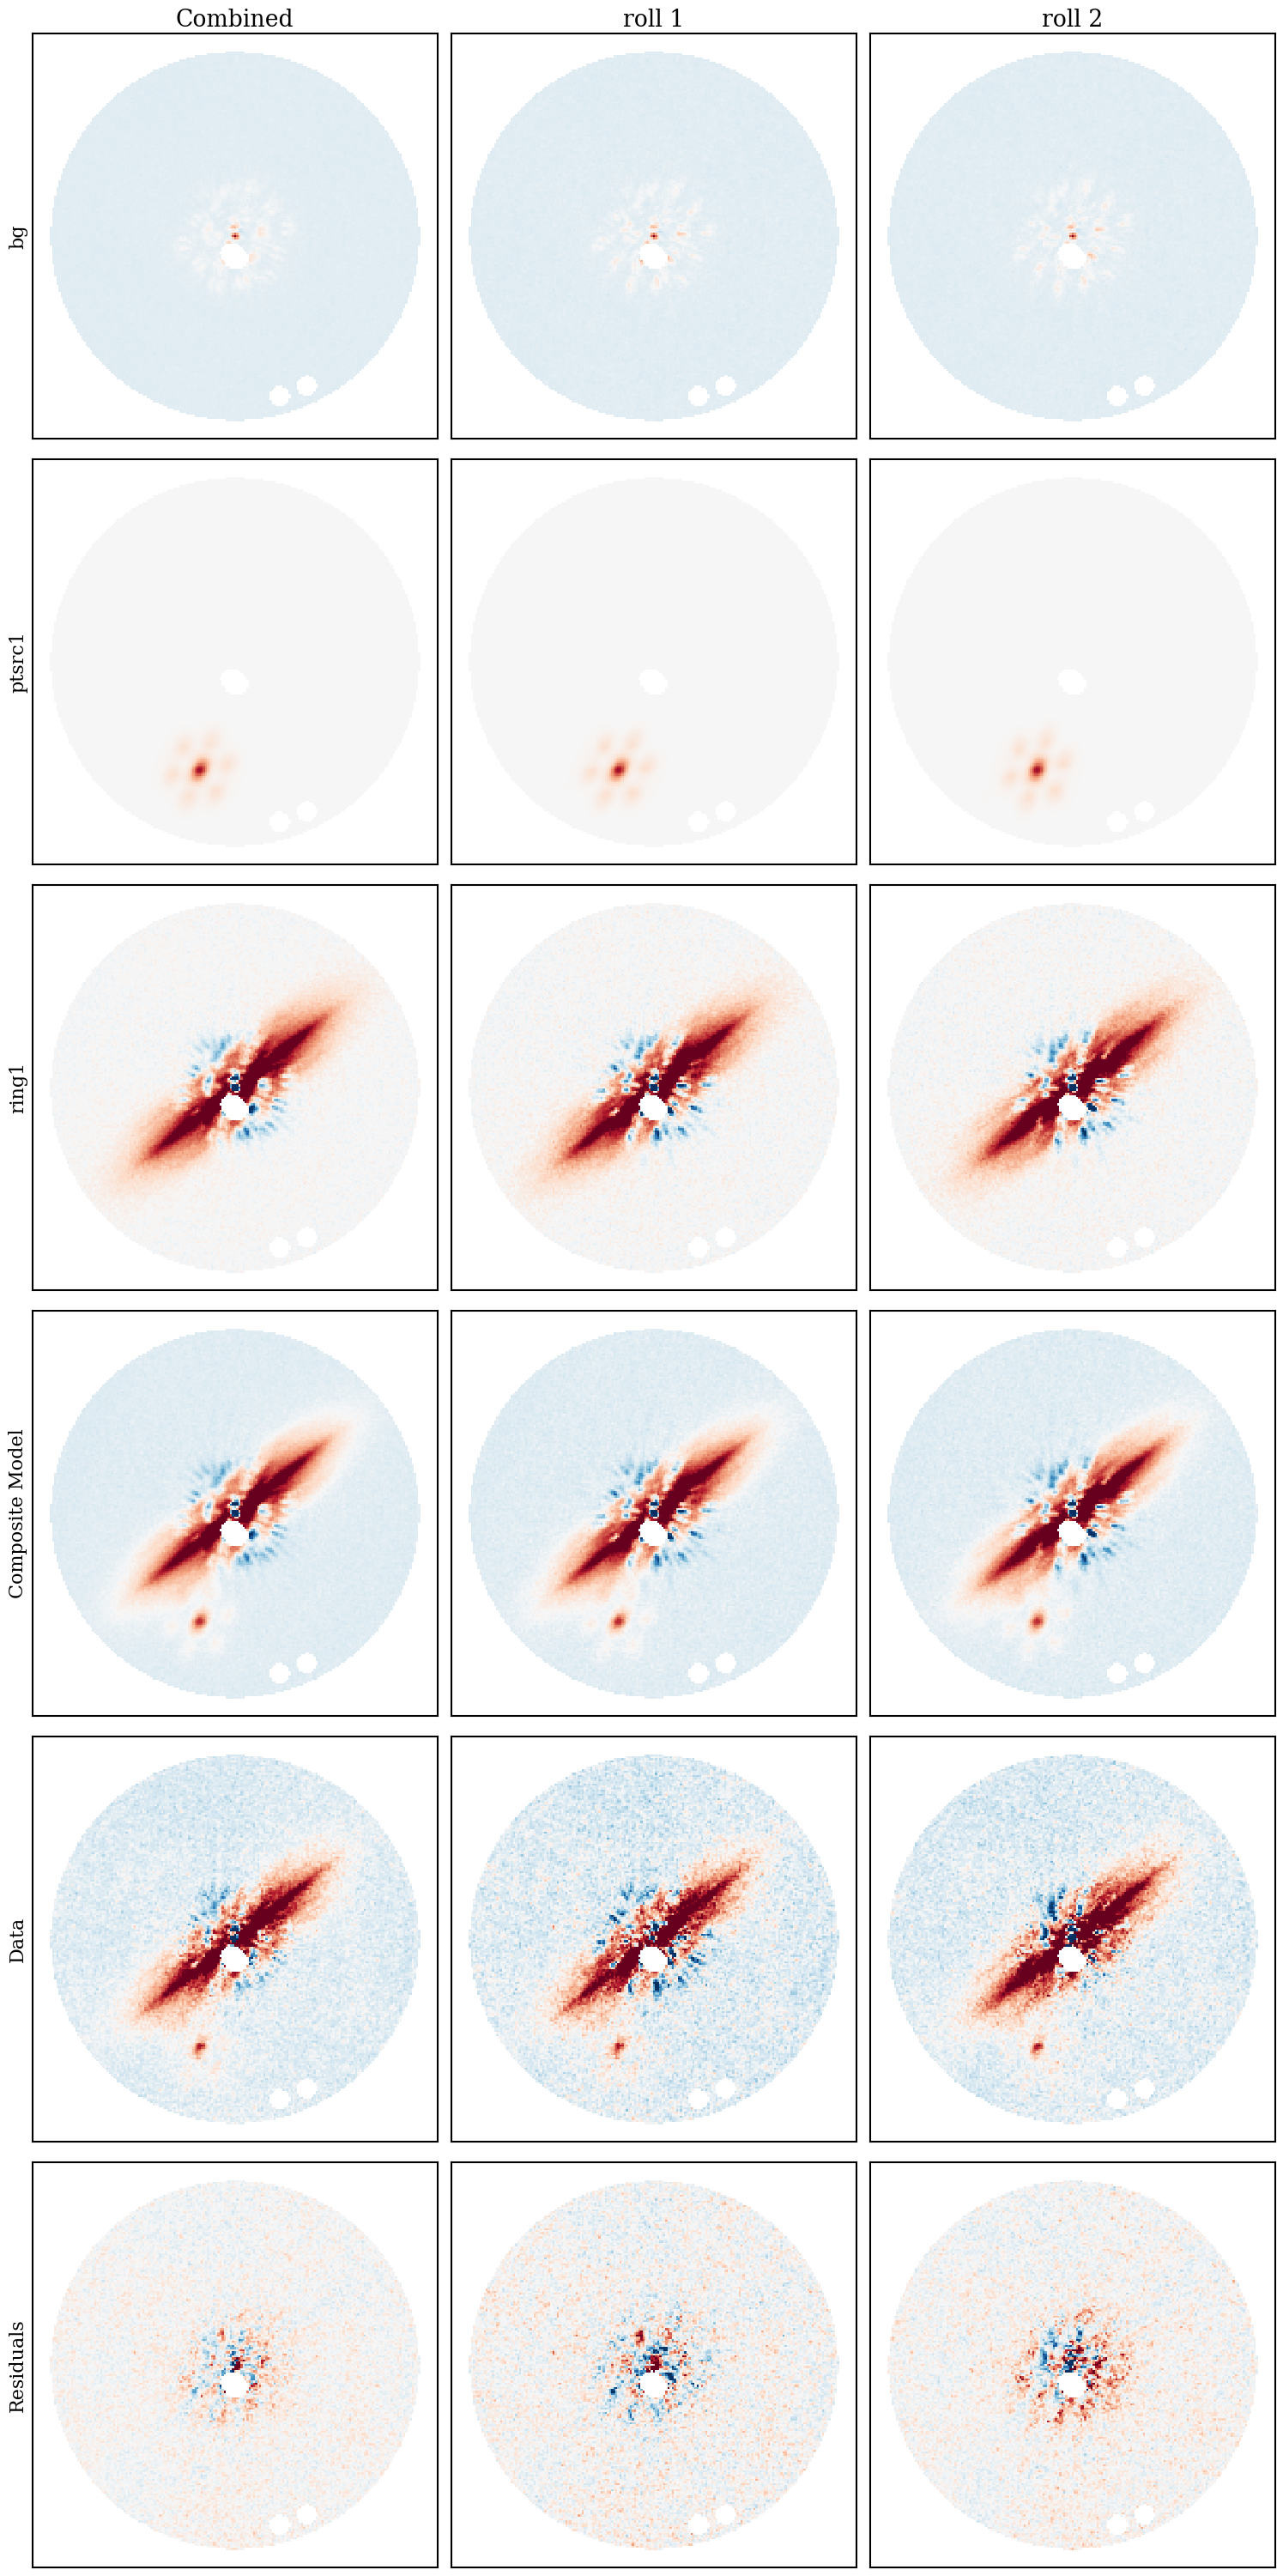

In [12]:
# Plot combined, roll1, roll2 for all parts:
pim = np.hstack((np.array([*[fmreduc.im for fmreduc in fmreducs], fmrdi_reduc.im, rdi_reduc.im, rdi_reduc.im-fmrdi_reduc.im])[:,None],
                 np.array([*[fmreduc.rolls for fmreduc in fmreducs], fmrdi_reduc.rolls, rdi_reduc.rolls, rdi_reduc.rolls-fmrdi_reduc.rolls])))

fig,axes = quick_implot(np.where(roi, pim, np.nan), clim_perc=99., extent=rdi_reduc.extent, lims=np.array([-1.1,1.1])*roi_rmax, cmap='RdBu_r', show=False, interpolation='None')

rlabels = [*modellabels, 'Composite Model', 'Data', 'Residuals']
clabels = ['Combined', *[f'roll {i+1}' for i in range(len(rdi_reduc.rolls))]]

for i,rlabel in enumerate(rlabels):
    axes[::len(clabels)][i].set_ylabel(rlabel)
    
for i,clabel in enumerate(clabels):
    axes[i].set_title(clabels[i])
    
plt.show()

In [13]:
# Save derotated results (composite and per-component, with and without RDI FM)

# Make a dictionary with some extra info about the best-fit model and optimization settings
model_dict = res.params.valuesdict()
model_dict.update(dict(q_clip=str(q_clip), err_weighting=err_weighting))

fmrdi_reduc.save(overwrite=True)
model_reduc.save(overwrite=True)

for i in range(len(modellabels)):
    model_dict[f'comp_{i+1}'] = modellabels[i]
    model_dict[f'coeff_{i+1}'] = modelcoeffs[i]

for modelreduc_i, fmreduc_i in zip(modelreducs, fmreducs):
    fmreduc_i.primary_header.update(model_dict)
    fmreduc_i.save(overwrite=True)
    
    modelreduc_i.primary_header.update(model_dict)
    modelreduc_i.save(overwrite=True)

Note: with the default "autoscale" behavior for components in obj_fn, the brightness of each component is not varied as a parameter in LMFit.

In this case, the flux of the 'point' source in mJy would be the entry in modelcoeffs corresponding to 'ptsrc1' in modellabels (index 1 here).

In [14]:
i = 1

print(f'{modellabels[i]}: F = {modelcoeffs[i]:0.2g} mJy')

ptsrc1: F = 0.057 mJy


Similarly, the entry in modelcoeffs corresponding to the pre-proc induced background offset (index 0 here) indicates the background surface brightness in units of MJy/Sr

(Since this background level is not astrophysical, it can be negative — and should be, since the background we added was negative)

In [15]:
i = 0

print(f'{modellabels[i]}: SB = {modelcoeffs[i]:0.2g} MJy/sr')

bg: SB = -0.5 MJy/sr


For any disk components, interpreting the value of the corresponding modelcoeffs entry is less straightforward. 

Most accurately, it would correspond to the value of 'dens_at_r0' in VIP's ScatteredLightDisk class.

If you want it to map to some vaguely meaningful brightness value, you can add an entry to your LMFit parameters object before fitting as follows:

`p.add("flux_max_1", value=1, vary=False)`

In this case, the generated model's flux is normalized to a peak surface brightness value of 1 before convolution, so the modelcoeffs entry would indicate the peak unconvolved surface brightness (**for the spatial sampling used when generating the model**) in units of MJy/sr. 

However, as a warning: since we have basically zero sensitivity at the brightest part of the disk here (very high mask attenuation where the forward-scattering peak would be), flux_max is not going to provide any meaningful information for us.

If you want to use an MCMC-like procedure to get an uncertainty on the point source flux, you can just set 

`p['ptsrc_flux_1'].vary=True`

before running your MCMC-like procedure. `obj_fn` will assume that this means you want autoscaling turned off for this model component, and will proceed accordingly.

Alternatively, leaving vary=False and setting the value != 1 will also turn off autoscaling.

(likewise for ring components with either flux_max_1 or F_1)

[spaceKLIP.database:WARNING]   --> Could not find KL mode in header, assuming default value of 50


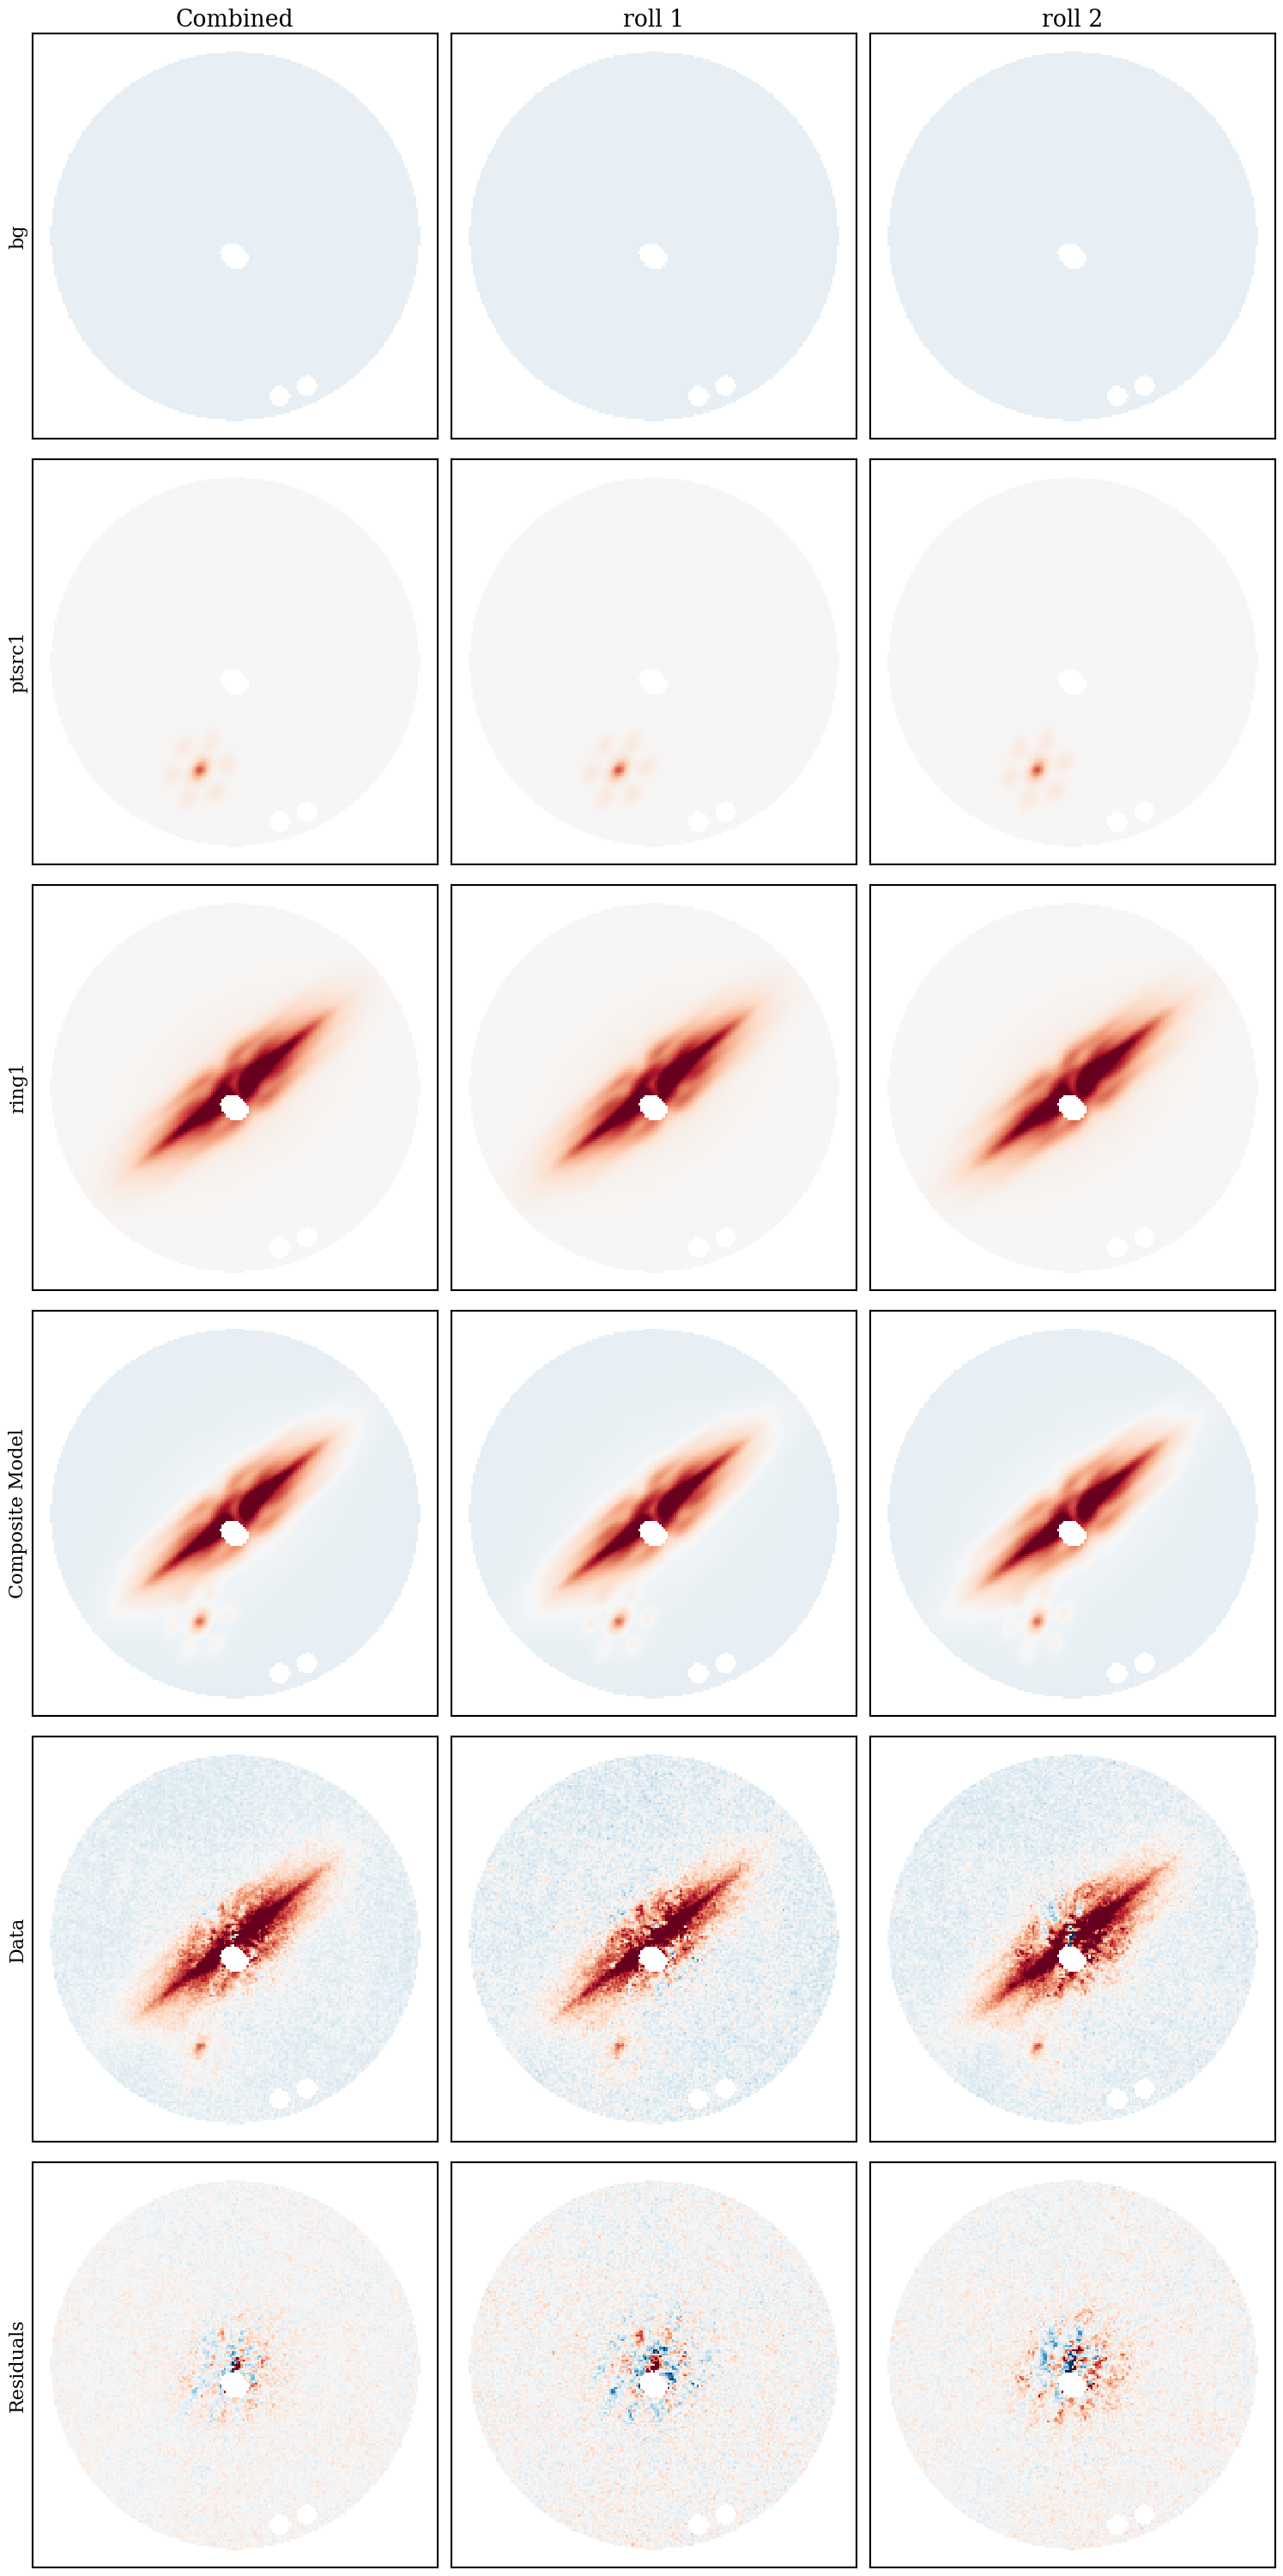

In [16]:
# Optionally run an MCRDI reduction and compare the results the same way

wdb.mcrdi_presets()
mcrdi_reduc = wdb.run_rdi(save_products=True)

# Plot combined, roll1, roll2 for all parts for MCRDI:

pim = np.hstack((np.array([*[modelreduc.im for modelreduc in modelreducs], model_reduc.im, mcrdi_reduc.im, mcrdi_reduc.im-model_reduc.im])[:,None],
                 np.array([*[modelreduc.rolls for modelreduc in modelreducs], model_reduc.rolls, mcrdi_reduc.rolls, mcrdi_reduc.rolls-model_reduc.rolls])))

fig,axes = quick_implot(np.where(roi, pim, np.nan), clim_perc=99., extent=rdi_reduc.extent, lims=np.array([-1.1,1.1])*roi_rmax, cmap='RdBu_r', show=False, interpolation='None')

rlabels = [*modellabels, 'Composite Model', 'Data', 'Residuals']
clabels = ['Combined', *[f'roll {i+1}' for i in range(len(rdi_reduc.rolls))]]

for i,rlabel in enumerate(rlabels):
    axes[::len(clabels)][i].set_ylabel(rlabel)
    
for i,clabel in enumerate(clabels):
    axes[i].set_title(clabels[i])
    
plt.show()

For many science applications, we may want to analyze the data reduction with some nuisance model component(s) subtracted. 

E.g., if we're interested in disk surface brightness, the background offset is going to be an issue (likewise if we want to deconvolve the data).

Or if we've modeled a bright background star in the data, we may just want to subtract off the best-fit model of the background star and work with the residuals.

To make this easier: Winnie's SpaceReduction objects (rdi_reduc, etc) now support arithmetic operations and will (hopefully) make sure you're not subtracting a derotated reduction from a non-derotated reduction (etc.).

So, we can subtract any model component from the corresponding reduction (making sure to subtract forward-modeled reducs from the RDI reduction and non-forward-modeled reducs from the MCRDI reduction).

In [17]:
mcrdi_bgsub = mcrdi_reduc - modelreducs[0]

rdi_bgsub = rdi_reduc - fmreducs[0]

We can do the same thing to the corresponding composite model reductions as well, so that our residuals still match:

In [18]:
model_bgsub = model_reduc - modelreducs[0]

fmrdi_bgsub = fmrdi_reduc - fmreducs[0]

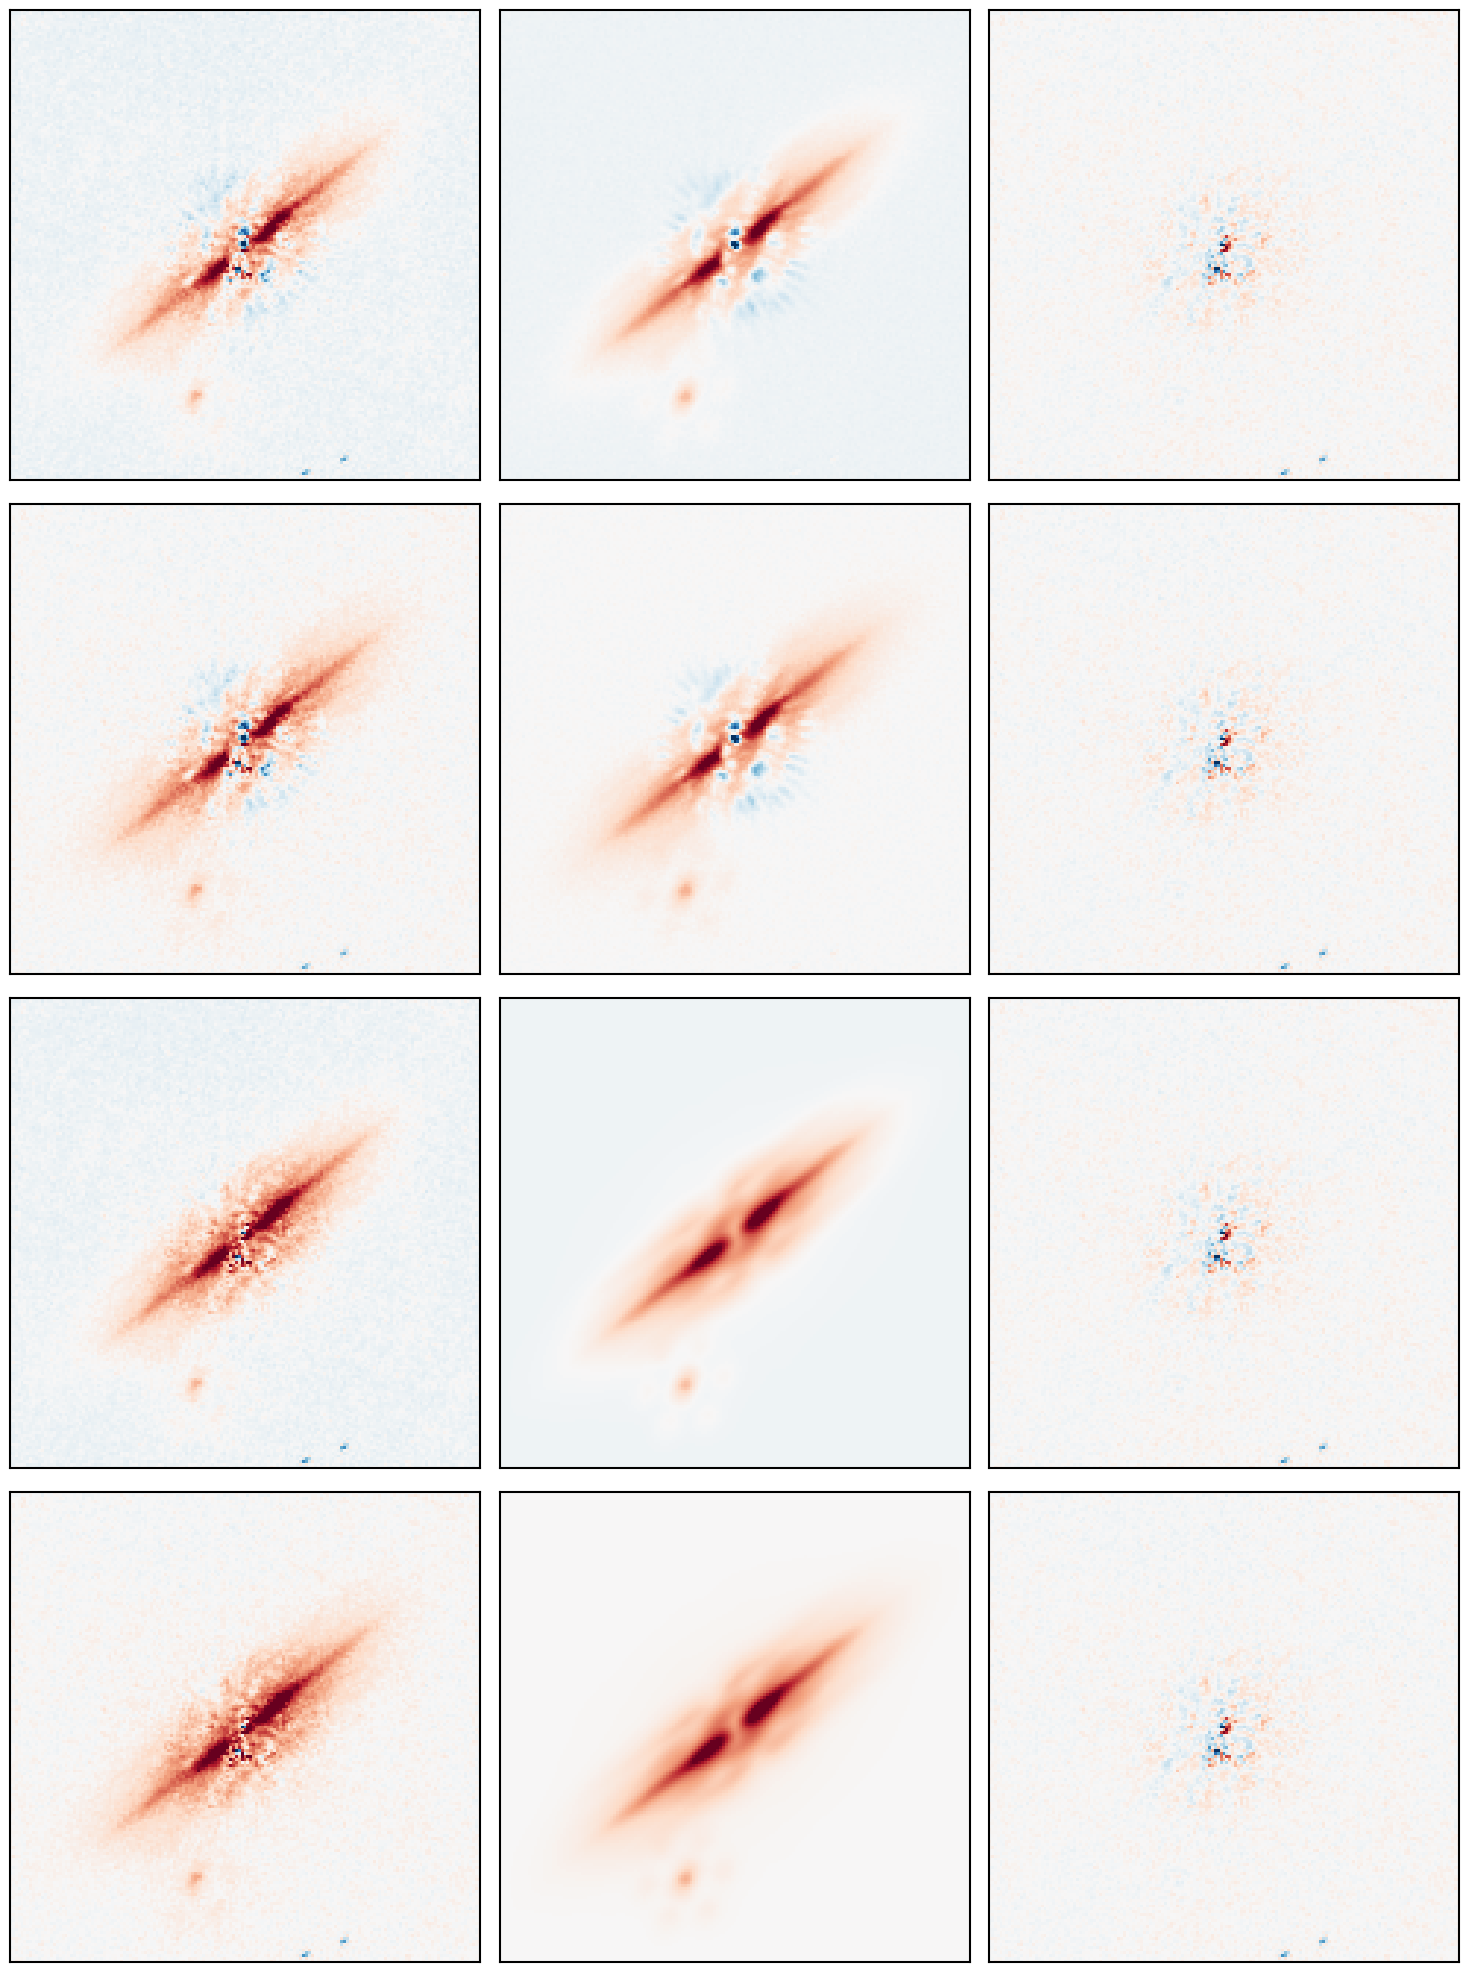

In [19]:
quick_implot([[rdi_reduc.im, fmrdi_reduc.im, rdi_reduc.im-fmrdi_reduc.im],
              [rdi_bgsub.im, fmrdi_bgsub.im, rdi_bgsub.im-fmrdi_bgsub.im],
              [mcrdi_reduc.im, model_reduc.im, mcrdi_reduc.im-model_reduc.im],
              [mcrdi_bgsub.im, model_bgsub.im, mcrdi_bgsub.im-model_bgsub.im]],
             cmap='RdBu_r', clim_perc=99.95, extent=rdi_reduc.extent, lims=[-5,5], interpolation='None')

Please keep in mind that (at least for now): the book-keeping for this is on you! For `C = A - B` for SpaceReductions `A` and `B`, `C` will inherit the headers, output_ext, filename, etc, of the leading term (`A` here). Before saving the result, you should consider at least updating the output_ext and reduc_label using the `update_output_ext` and `update_reduc_label` methods. E.g.,

```
C.update_output_ext('AsubB')
C.update_reduc_label('A - B')
C.save()
```

In case it's useful, here's a helper function to handle this:

In [20]:
from copy import deepcopy

def subtract_nuisance_model_components(data_reduc, model_reducs, model_labels, nuisance_labels, save_products=False, overwrite=False):
    model_labels = np.asarray(model_labels)
    reduc_out = deepcopy(data_reduc)
    for nuisance_label in nuisance_labels:
        nuisance_ind = np.argmax(model_labels == nuisance_label)
        if nuisance_label != model_labels[nuisance_ind]:
            raise ValueError(f'No entry with label "{nuisance_label}" is present in model_labels.')
            
        reduc_out -= model_reducs[nuisance_ind]
        reduc_out.update_output_ext(reduc_out.output_ext + '_' + nuisance_label.replace('_','') + 'sub')
        reduc_out.update_reduc_label(reduc_out.reduc_label + ' - ' + nuisance_label)
        
    if save_products:
        reduc_out.save(overwrite=overwrite)
        
    return reduc_out

In [21]:
mcrdi_bgsub = subtract_nuisance_model_components(mcrdi_reduc, modelreducs, modellabels, ['bg'], save_products=True, overwrite=True)
mcrdi_bgsub_ptsrcsub = subtract_nuisance_model_components(mcrdi_reduc, modelreducs, modellabels, ['bg', 'ptsrc1'], save_products=True, overwrite=True)

for r in [mcrdi_bgsub, mcrdi_bgsub_ptsrcsub]:
    print(r.output_ext)
    print(r.reduc_label)
    print(r.filename.split('/')[-1])
    print('')

mcrdi_psfsub_bgsub
MCRDI - bg
JWST_NIRCAM_NRCALONG_F444W_MASKRND_MASK335R_SUB320A335R_mcrdi_psfsub_bgsub_i2d.fits

mcrdi_psfsub_bgsub_ptsrc1sub
MCRDI - bg - ptsrc1
JWST_NIRCAM_NRCALONG_F444W_MASKRND_MASK335R_SUB320A335R_mcrdi_psfsub_bgsub_ptsrc1sub_i2d.fits



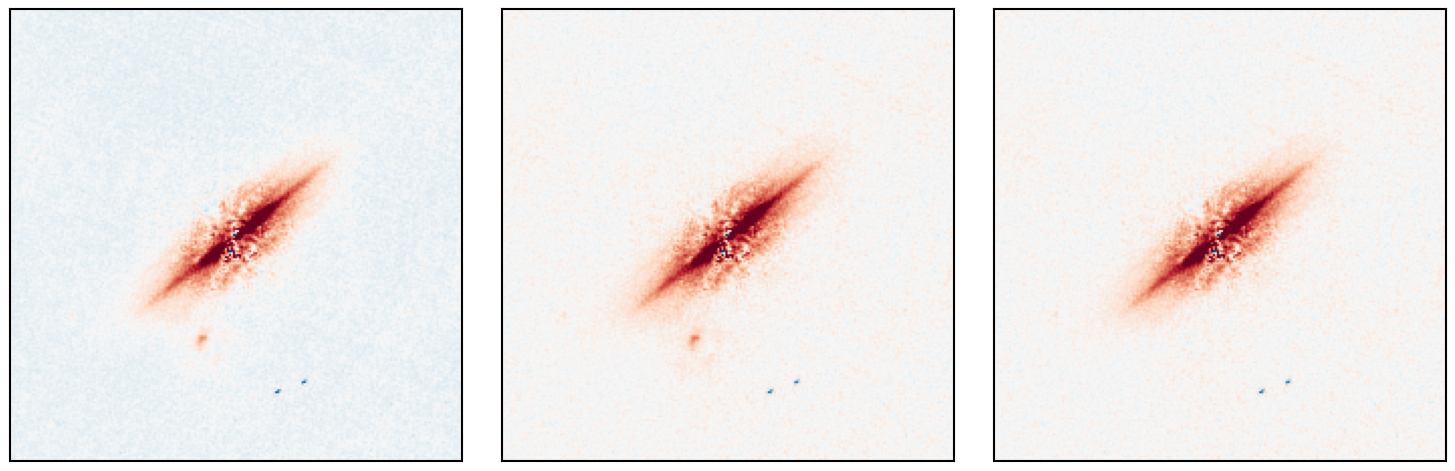

In [22]:
quick_implot([mcrdi_reduc.im, mcrdi_bgsub.im, mcrdi_bgsub_ptsrcsub.im], extent=mcrdi_reduc.extent, lims=[-7,7], cmap='RdBu_r', clim_perc=99.8)